# Exploration EDAs: extra song data sources

Checks how many MuSe songs we can join to data sources other than lyrics:

1. **Spotify audio features**: three Kaggle dumps, joined by Spotify ID and by (artist, title).
2. **AcousticBrainz**: per-recording descriptors (mood, genre, key, tempo), joined by MusicBrainz ID through the API, so we fetch only MuSe's recordings, not the full dump.
3. **Spotify Million Playlist Dataset**: how many MuSe songs appear in at least one playlist.

Runs top to bottom from `proposal/`. Needs `pandas`, `matplotlib` and `kagglehub` (public Kaggle datasets download without a login).

In [1]:
import json
import re
import threading
import time
import unicodedata
import urllib.request
import zipfile
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from urllib.error import HTTPError, URLError

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("../data/raw")
INTERIM = Path("../data/interim")

muse = pd.read_csv(DATA / "muse" / "muse_v3.csv")
print(f"{len(muse):,} MuSe songs")
print(f"  with spotify_id: {muse['spotify_id'].notna().sum():,} ({muse['spotify_id'].notna().mean():.1%})")
print(f"  with mbid:       {muse['mbid'].notna().sum():,} ({muse['mbid'].notna().mean():.1%})")

C:\Users\mouka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


90,001 MuSe songs
  with spotify_id: 61,630 (68.5%)
  with mbid:       61,217 (68.0%)


## 1. Spotify audio features (Kaggle)

Spotify closed its audio-features endpoint to new apps in Nov 2024, so these dumps are the only source. All three were collected from the Spotify API before then.

| Name | Kaggle dataset | ID column |
|---|---|---|
| `spotify_12m` | [rodolfofigueroa/spotify-12m-songs](https://www.kaggle.com/datasets/rodolfofigueroa/spotify-12m-songs) | `id` |
| `spotify_1m` | [amitanshjoshi/spotify-1million-tracks](https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks) | `track_id` |
| `spotify_114k` | [maharshipandya/-spotify-tracks-dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) | `track_id` |

Each has the same audio features (danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo). We join two ways:

- **By ID:** MuSe `spotify_id` = the dataset's track ID. Exact, but 31.5% of MuSe songs have no `spotify_id`, and one song can have several Spotify IDs (single, album, remaster).
- **By name:** normalised first artist + title. This catches songs whose ID differs or is missing. Normalising lower-cases, strips accents, drops bracketed parts like *(feat. X)* or *[Remastered]*, drops a trailing *" - 2011 Remaster"*, and keeps only letters and digits.

In [2]:
SPOTIFY = {  # name: (kaggle slug, file, id column, title column, artist column)
    "spotify_12m": ("rodolfofigueroa/spotify-12m-songs", "tracks_features.csv", "id", "name", "artists"),
    "spotify_1m": ("amitanshjoshi/spotify-1million-tracks", "spotify_data.csv", "track_id", "track_name", "artist_name"),
    "spotify_114k": ("maharshipandya/-spotify-tracks-dataset", "dataset.csv", "track_id", "track_name", "artists"),
}


def norm(s):
    """Lower-case, strip accents, brackets and ' - Remaster' suffixes; keep letters and digits."""
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()
    s = re.sub(r"\(.*?\)|\[.*?\]", " ", s)
    s = re.sub(r"\s-\s.*$", " ", s)
    return re.sub(r"[^a-z0-9]+", " ", s).strip()


def first_artist(s):
    """First artist from "['A', 'B']" (12m) or "A;B" (114k) or a plain name (1m)."""
    s = str(s)
    if s.startswith("["):
        s = s[1:-1].split(",")[0].strip().strip("'\"")
    return s.split(";")[0]


spot = {}
for name, (slug, file, id_col, title_col, artist_col) in SPOTIFY.items():
    path = Path(kagglehub.dataset_download(slug)) / file
    df = pd.read_csv(path, usecols=[id_col, title_col, artist_col])
    df = df.rename(columns={id_col: "track_id", title_col: "title", artist_col: "artist"})
    df["key"] = df["artist"].map(first_artist).map(norm) + " | " + df["title"].map(norm)
    spot[name] = df
    print(f"{name}: {len(df):,} rows, {df['track_id'].nunique():,} unique IDs")

muse["key"] = muse["artist"].map(norm) + " | " + muse["track"].map(norm)

spotify_12m: 1,204,025 rows, 1,204,025 unique IDs


spotify_1m: 1,159,764 rows, 1,159,764 unique IDs


spotify_114k: 114,000 rows, 89,741 unique IDs


In [3]:
match = pd.DataFrame(index=muse.index)
rows = []
for name, df in spot.items():
    by_id = muse["spotify_id"].isin(set(df["track_id"]))
    by_name = muse["key"].isin(set(df["key"]))
    match[name] = by_id | by_name
    match[f"{name}_by_id"] = by_id
    rows.append({
        "dataset": name,
        "by ID": by_id.sum(),
        "by name only": (by_name & ~by_id).sum(),
        "either": (by_id | by_name).sum(),
        "either %": f"{(by_id | by_name).mean():.1%}",
    })
pd.DataFrame(rows).set_index("dataset")

,by ID,by name only,either,either %
dataset,,,,
spotify_12m,9227,6455,15682,17.4%
spotify_1m,14415,12915,27330,30.4%
spotify_114k,1273,2345,3618,4.0%


**Sanity check on name matching.** For songs matched by ID, how often does the name key also match? A low rate would mean the normalisation misses true matches.

In [4]:
for name, df in spot.items():
    ided = muse[match[f"{name}_by_id"]]
    keys_of_id = df.drop_duplicates("track_id").set_index("track_id")["key"]
    agree = (ided["key"] == ided["spotify_id"].map(keys_of_id)).mean()
    print(f"{name}: name key agrees for {agree:.1%} of {len(ided):,} ID matches")

spotify_12m: name key agrees for 92.4% of 9,227 ID matches


spotify_1m: name key agrees for 92.8% of 14,415 ID matches
spotify_114k: name key agrees for 89.2% of 1,273 ID matches


### How many Spotify datasets does each MuSe song appear in?

Counted twice: by ID only (strict), and by ID or name.

In [5]:
names = list(SPOTIFY)
n_by_id = match[[f"{n}_by_id" for n in names]].sum(axis=1)
n_either = match[names].sum(axis=1)
overlap = pd.DataFrame({
    "by ID": n_by_id.value_counts().sort_index(),
    "by ID or name": n_either.value_counts().sort_index(),
}).fillna(0).astype(int)
overlap.index.name = "datasets matched"
overlap["by ID %"] = (overlap["by ID"] / len(muse)).map("{:.1%}".format)
overlap["by ID or name %"] = (overlap["by ID or name"] / len(muse)).map("{:.1%}".format)
overlap

,by ID,by ID or name,by ID %,by ID or name %
datasets matched,,,,
0,68431,54533,76.0%,60.6%
1,18347,25958,20.4%,28.8%
2,3101,7858,3.4%,8.7%
3,122,1652,0.1%,1.8%


In [6]:
# Which combination of datasets (ID or name). 1 = matched.
combo = match[names].astype(int).value_counts().rename("songs").reset_index()
combo["%"] = (combo["songs"] / len(muse)).map("{:.1%}".format)
combo

,spotify_12m,spotify_1m,spotify_114k,songs,%
0,0,0,0,54533,60.6%
1,0,1,0,17927,19.9%
2,1,0,0,7691,8.5%
3,1,1,0,6232,6.9%
4,1,1,1,1652,1.8%
5,0,1,1,1519,1.7%
6,0,0,1,340,0.4%
7,1,0,1,107,0.1%


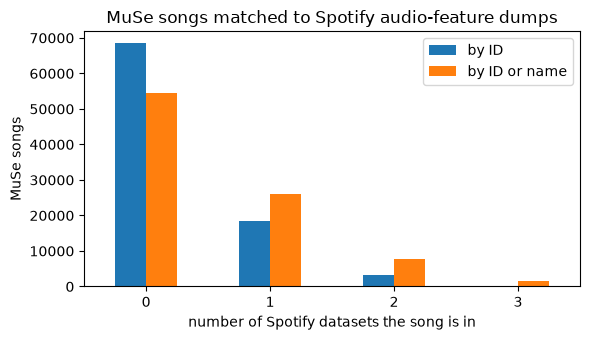

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
overlap[["by ID", "by ID or name"]].plot.bar(ax=ax, rot=0)
ax.set_xlabel("number of Spotify datasets the song is in")
ax.set_ylabel("MuSe songs")
ax.set_title("MuSe songs matched to Spotify audio-feature dumps")
plt.tight_layout()
plt.show()

In [8]:
spotify_any = match[names].any(axis=1)
print(f"MuSe songs with audio features from at least 1 dataset: {spotify_any.sum():,} ({spotify_any.mean():.1%})")

INTERIM.mkdir(parents=True, exist_ok=True)
out = pd.concat([muse[["lastfm_url"]], match.astype(int)], axis=1)
out.to_csv(INTERIM / "muse_spotify_coverage.csv", index=False)

MuSe songs with audio features from at least 1 dataset: 35,468 (39.4%)


## 2. AcousticBrainz

AcousticBrainz stopped taking submissions in 2022. Its data is computed: volunteers ran the Essentia extractor on their own audio files, and the high-level values (`mood_sad` etc.) are classifier predictions. One recording can have several submissions.

**Downloading only MuSe's tracks.** The [full dumps](https://data.metabrainz.org/pub/musicbrainz/acousticbrainz/dumps/) come as many 1–2 GB `.tar.zst` parts. The [API](https://acousticbrainz.readthedocs.io/api.html) is still up and takes 25 MBIDs per call, so we fetch only MuSe's recordings:

- `count`: number of submissions per MBID. Cheap, used for coverage.
- `high-level`: the classifier outputs (mood, genre, danceability, timbre...).
- `low-level` with `features=`: only the named low-level fields, e.g. key scale and BPM.

Limits: 100 requests per 10 s. The server is slow (~3 s per `count` call, ~25 s per `high-level` call), so we use 16 threads. Responses are cached in `data/raw/acousticbrainz/`, so a rerun resumes where it stopped.

Only MuSe songs with an `mbid` (68%) can join.

In [9]:
AB_API = "https://acousticbrainz.org/api/v1"
AB_DIR = DATA / "acousticbrainz"
AB_DIR.mkdir(parents=True, exist_ok=True)
BATCH = 25
THREADS = 16
_slot = threading.Lock()
_next_time = [0.0]


def ab_get(endpoint, mbids, params=""):
    """One API call for up to 25 MBIDs, spaced at most 10/s, with retries."""
    url = f"{AB_API}/{endpoint}?recording_ids={';'.join(mbids)}{params}"
    for attempt in range(6):
        with _slot:  # space request starts 0.11 s apart, under the 100 per 10 s limit
            wait = _next_time[0] - time.time()
            _next_time[0] = max(_next_time[0], time.time()) + 0.11
        if wait > 0:
            time.sleep(wait)
        try:
            with urllib.request.urlopen(url, timeout=180) as r:
                return json.load(r)
        except HTTPError as e:
            if e.code == 429:
                time.sleep(int(e.headers.get("X-RateLimit-Reset-In", 10)) + 1)
            elif e.code < 500:
                raise
            else:
                time.sleep(2 ** attempt)
        except (URLError, TimeoutError, ConnectionError):
            time.sleep(2 ** attempt)
    raise RuntimeError(f"gave up on {endpoint} batch starting {mbids[0]}")


def ab_fetch(endpoint, mbids, cache, parse, params=""):
    """Fetch all MBIDs not in the jsonl cache; parse(body, batch) returns one record per MBID."""
    done = set()
    if cache.exists():
        with cache.open(encoding="utf-8") as f:
            done = {json.loads(line)["mbid"] for line in f}
    todo = [m for m in mbids if m not in done]
    batches = [todo[i:i + BATCH] for i in range(0, len(todo), BATCH)]
    print(f"{endpoint}: {len(done):,} cached, {len(todo):,} to fetch in {len(batches):,} calls")
    write = threading.Lock()
    start = time.time()
    with cache.open("a", encoding="utf-8") as f, ThreadPoolExecutor(THREADS) as ex:
        for i, (batch, body) in enumerate(zip(batches, ex.map(lambda b: ab_get(endpoint, b, params), batches))):
            with write:
                for rec in parse(body, batch):
                    f.write(json.dumps(rec) + "\n")
            if (i + 1) % 200 == 0:
                print(f"  {i + 1:,}/{len(batches):,} calls, {time.time() - start:.0f} s")
    with cache.open(encoding="utf-8") as f:
        return pd.DataFrame([json.loads(line) for line in f]).drop_duplicates("mbid", keep="last")


muse_mbids = muse["mbid"].dropna().unique().tolist()

### Coverage (`count`)

About 2,450 calls, roughly 10 minutes on a first run.

In [10]:
def parse_count(body, batch):
    return [{"mbid": m, "count": body.get(m, {}).get("count", 0)} for m in batch]


ab_count = ab_fetch("count", muse_mbids, AB_DIR / "count.jsonl", parse_count)
has_ab = muse["mbid"].isin(set(ab_count.loc[ab_count["count"] > 0, "mbid"]))

print(f"MuSe songs with an mbid:          {muse['mbid'].notna().sum():,}")
print(f"  ...with >=1 AcousticBrainz entry: {has_ab.sum():,} ({has_ab.mean():.1%} of all MuSe)")
ab_count.loc[ab_count["count"] > 0, "count"].describe(percentiles=[0.5, 0.9]).round(1)

count: 0 cached, 61,217 to fetch in 2,449 calls


  200/2,449 calls, 41 s


  400/2,449 calls, 64 s


  600/2,449 calls, 119 s


  800/2,449 calls, 148 s


...

  2,000/2,449 calls, 435 s


  2,200/2,449 calls, 465 s


  2,400/2,449 calls, 497 s


MuSe songs with an mbid:          61,217
  ...with >=1 AcousticBrainz entry: 48,898 (54.3% of all MuSe)


count    48898.0
mean        18.0
std         32.8
min          1.0
50%          6.0
90%         47.0
max        664.0
Name: count, dtype: float64

### AcousticBrainz and Spotify together

In [11]:
both = pd.crosstab(
    has_ab.rename("AcousticBrainz"),
    spotify_any.rename("Spotify (>=1 dataset)"),
    margins=True,
)
both

Spotify (>=1 dataset),False,True,All
AcousticBrainz,,,
False,30030,11073,41103
True,24503,24395,48898
All,54533,35468,90001


In [12]:
print(f"Songs with AcousticBrainz OR Spotify features: {(has_ab | spotify_any).sum():,} ({(has_ab | spotify_any).mean():.1%})")
print(f"Songs with neither:                            {(~has_ab & ~spotify_any).sum():,}")

Songs with AcousticBrainz OR Spotify features: 59,971 (66.6%)
Songs with neither:                            30,030


### Feature download (optional)

Set `FETCH_AB_FEATURES = True` to fetch the features for every covered MBID. We keep the first submission only (`n=0`), and keep only the class probabilities from `high-level` (no version or file metadata). From `low-level` we keep `tonal.key_scale`, `tonal.key_key`, `tonal.chords_scale`, `rhythm.bpm` and `lowlevel.average_loudness`.

`high-level` calls take ~25 s each, so a first run of ~2,000 calls takes about an hour at 16 threads. It resumes from the cache if stopped.

In [13]:
FETCH_AB_FEATURES = False
LOW_FEATURES = ["tonal.key_scale", "tonal.key_key", "tonal.chords_scale", "rhythm.bpm", "lowlevel.average_loudness"]


def parse_high(body, batch):
    recs = []
    for m in batch:
        hl = body.get(m, {}).get("0", {}).get("highlevel")
        if hl:
            probs = {f"{clf}.{cls}": p for clf, v in hl.items() for cls, p in v["all"].items()}
            recs.append({"mbid": m, **probs})
        else:
            recs.append({"mbid": m})
    return recs


def parse_low(body, batch):
    recs = []
    for m in batch:
        sub = body.get(m, {}).get("0", {})
        rec = {"mbid": m}
        for feat in LOW_FEATURES:
            group, key = feat.split(".")
            rec[feat] = sub.get(group, {}).get(key)
        recs.append(rec)
    return recs


if FETCH_AB_FEATURES:
    covered = ab_count.loc[ab_count["count"] > 0, "mbid"].tolist()
    ab_high = ab_fetch("high-level", covered, AB_DIR / "highlevel.jsonl", parse_high)
    ab_low = ab_fetch("low-level", covered, AB_DIR / "lowlevel.jsonl", parse_low,
                      params="&features=" + ";".join(LOW_FEATURES))
    ab_feats = ab_high.merge(ab_low, on="mbid", how="outer")
    ab_feats.to_csv(INTERIM / "acousticbrainz_features.csv", index=False)
    print(f"{len(ab_feats):,} recordings x {ab_feats.shape[1] - 1} features")
else:
    print("Skipped. Set FETCH_AB_FEATURES = True to download the features.")

Skipped. Set FETCH_AB_FEATURES = True to download the features.


## 3. Spotify Million Playlist Dataset (MPD)

**Not available to download any more.** AIcrowd removed it and says to [ask Spotify Research](https://www.aicrowd.com/challenges/spotify-million-playlist-dataset-challenge) for access. The terms forbid redistribution, so Kaggle or GitHub mirrors break them; don't use those.

Only songs with a `spotify_id` can join (MPD stores Spotify track URIs). The MPD ends in 2017.

If access comes through, put the zip at `data/raw/mpd/spotify_million_playlist_dataset.zip` and rerun. The cell streams the 1,000 JSON slices from the zip without extracting it. For each MuSe song it counts how many playlists contain it and which playlist names they have.

In [14]:
MPD_ZIP = DATA / "mpd" / "spotify_million_playlist_dataset.zip"

if not MPD_ZIP.exists():
    print(f"MPD not found at {MPD_ZIP}. Skipped.")
else:
    muse_uris = set("spotify:track:" + muse["spotify_id"].dropna())
    playlist_names = defaultdict(Counter)  # uri -> Counter of lower-cased playlist names
    with zipfile.ZipFile(MPD_ZIP) as z:
        slices = [n for n in z.namelist() if re.search(r"mpd\.slice\..*\.json$", n)]
        for i, slice_name in enumerate(slices):
            for pl in json.loads(z.read(slice_name))["playlists"]:
                name = pl["name"].strip().lower()
                for uri in {t["track_uri"] for t in pl["tracks"]} & muse_uris:
                    playlist_names[uri][name] += 1
            if (i + 1) % 100 == 0:
                print(f"  {i + 1}/{len(slices)} slices")

    n_playlists = muse["spotify_id"].map(lambda s: sum(playlist_names[f"spotify:track:{s}"].values()) if pd.notna(s) else 0)
    print(f"MuSe songs in >=1 playlist: {(n_playlists >= 1).sum():,} ({(n_playlists >= 1).mean():.1%})")
    print(f"MuSe songs in >=5 playlists: {(n_playlists >= 5).sum():,}")
    with (INTERIM / "mpd_playlist_names.jsonl").open("w", encoding="utf-8") as f:
        for uri, names_ in playlist_names.items():
            f.write(json.dumps({"uri": uri, "names": dict(names_)}) + "\n")

MPD not found at ..\data\raw\mpd\spotify_million_playlist_dataset.zip. Skipped.
